##### **랜덤포레스트**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap

In [4]:
#데이터 로드
iris = load_iris() # 사이킷런에서 붓꽃데이터를 제공

In [5]:
# 독립, 종속 분리
X = iris.data[:, 2:4] # 2번째, 3번째 컬럼(petal length, petal width)
y = iris.target

In [6]:
#훈련, 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 학습
model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# 성능평가
accuracy = model .score(X_test_scaled, y_test)
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: 0.93


In [11]:
# 시각화 범위 설정 (스케일링 된 데이터 기준)
# -0.5, +0.5는 그래프 여백
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
hh = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, hh),
                     np.arange(y_min, y_max, hh))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

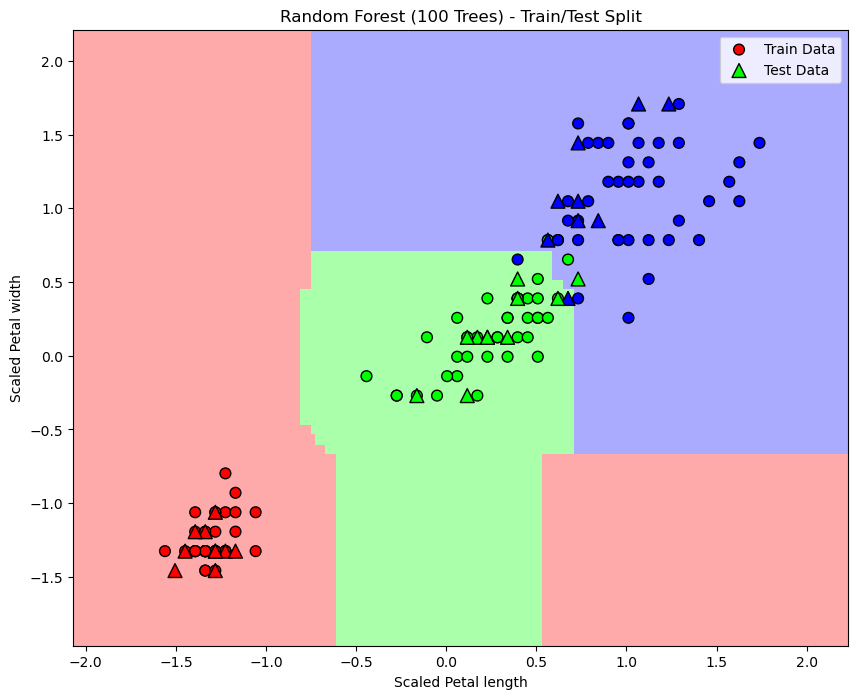

In [12]:
# 시각화
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# 훈련 데이터 (동그라미)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            cmap=cmap_bold, edgecolor='k', s=60, label='Train Data')

# 테스트 데이터 (삼각형)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
            cmap=cmap_bold, marker='^', edgecolor='k', s=100, label='Test Data')

plt.xlabel('Scaled Petal length')
plt.ylabel('Scaled Petal width')
plt.title('Random Forest (100 Trees) - Train/Test Split')
plt.legend()
plt.show()